<a href="https://colab.research.google.com/github/Haritha0105/Statistical-Learning-e21172/blob/main/Assigment_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

--------------------------------------------------------------------answers------------------------------------------------------------

### 1. Deriving the Prior Predictive State Distribution
We are given the state transition model:
$$x_{k}^{-} = A_{k-1}x_{k-1}^{+} + G_{k-1}w_{k-1}$$

Taking the expected value (mean) of both sides:
$$\mathbb{E}[x_{k}^{-}] = \mathbb{E}[A_{k-1}x_{k-1}^{+} + G_{k-1}w_{k-1}]$$
$$m_{k}^{-} = A_{k-1}\mathbb{E}[x_{k-1}^{+}] + G_{k-1}\mathbb{E}[w_{k-1}]$$

Since the noise is zero-mean ($\mathbb{E}[w_{k-1}] = 0$) and the prior mean is $m_{k-1}$:
$$m_{k}^{-} = A_{k-1}m_{k-1}$$

Taking the variance (covariance matrix) of both sides. Since $x_{k-1}^{+}$ and $w_{k-1}$ are independent:
$$\text{Var}(x_{k}^{-}) = \text{Var}(A_{k-1}x_{k-1}^{+}) + \text{Var}(G_{k-1}w_{k-1})$$
$$P_{k}^{-} = A_{k-1}\text{Var}(x_{k-1}^{+})A_{k-1}^{T} + G_{k-1}\text{Var}(w_{k-1})G_{k-1}^{T}$$
$$P_{k}^{-} = A_{k-1}P_{k-1}A_{k-1}^{T} + G_{k-1}\Sigma_{p}G_{k-1}^{T}$$

Since linear combinations of Gaussian variables are also Gaussian, we conclude:
$$x_{k}^{-} \sim \mathcal{N}(m_{k}^{-}, P_{k}^{-})$$

---

### 2. Deriving the Predictive Measurement Distribution
We are given the measurement model:
$$y_{k} = H_{k}x_{k}^{-} + z_{k}$$

Taking the expected value:
$$\mathbb{E}[y_{k}] = \mathbb{E}[H_{k}x_{k}^{-} + z_{k}] = H_{k}\mathbb{E}[x_{k}^{-}] + \mathbb{E}[z_{k}]$$

Since measurement noise is zero-mean ($\mathbb{E}[z_{k}] = 0$):
$$\mathbb{E}[y_{k}] = H_{k}m_{k}^{-}$$

Taking the variance. Since the predicted state $x_{k}^{-}$ and measurement noise $z_{k}$ are independent:
$$\text{Var}(y_{k}) = \text{Var}(H_{k}x_{k}^{-}) + \text{Var}(z_{k})$$
$$\text{Var}(y_{k}) = H_{k}\text{Var}(x_{k}^{-})H_{k}^{T} + \text{Var}(z_{k})$$
$$\text{Var}(y_{k}) = H_{k}P_{k}^{-}H_{k}^{T} + \Sigma_{m}$$

Therefore, the prior predictive measurement distribution (denoted as $y_{k}^{-}$) is:
$$y_{k}^{-} \sim \mathcal{N}(H_{k}m_{k}^{-}, H_{k}P_{k}^{-}H_{k}^{T} + \Sigma_{m})$$

---

### 3. Deriving the Joint Distribution
To formulate the joint distribution of $\begin{bmatrix} x_{k}^{-} \\ y_{k}^{-} \end{bmatrix}$, we need the cross-covariance terms between the state and the measurement.

The cross-covariance $\text{Cov}(x_{k}^{-}, y_{k}^{-})$ is:
$$\text{Cov}(x_{k}^{-}, y_{k}^{-}) = \mathbb{E}[(x_{k}^{-} - m_{k}^{-})(y_{k}^{-} - H_{k}m_{k}^{-})^{T}]$$

Substitute the measurement model $y_{k}^{-} = H_{k}x_{k}^{-} + z_{k}$:
$$\text{Cov}(x_{k}^{-}, y_{k}^{-}) = \mathbb{E}[(x_{k}^{-} - m_{k}^{-})(H_{k}(x_{k}^{-} - m_{k}^{-}) + z_{k})^{T}]$$
$$\text{Cov}(x_{k}^{-}, y_{k}^{-}) = \mathbb{E}[(x_{k}^{-} - m_{k}^{-})(x_{k}^{-} - m_{k}^{-})^{T}H_{k}^{T}] + \mathbb{E}[(x_{k}^{-} - m_{k}^{-})z_{k}^{T}]$$

Since $x_{k}^{-}$ and $z_{k}$ are independent, the expected value of their product is zero:
$$\text{Cov}(x_{k}^{-}, y_{k}^{-}) = P_{k}^{-}H_{k}^{T}$$

By symmetry, $\text{Cov}(y_{k}^{-}, x_{k}^{-}) = (\text{Cov}(x_{k}^{-}, y_{k}^{-}))^{T} = H_{k}P_{k}^{-}$.

Combining the means, variances (from parts 1 & 2), and cross-covariances, we get the joint Gaussian distribution:
$$\begin{bmatrix} x_{k}^{-} \\ y_{k}^{-} \end{bmatrix} \sim \mathcal{N}\left( \begin{bmatrix} m_{k}^{-} \\ H_{k}m_{k}^{-} \end{bmatrix}, \begin{bmatrix} P_{k}^{-} & P_{k}^{-}H_{k}^{T} \\ H_{k}P_{k}^{-} & H_{k}P_{k}^{-}H_{k}^{T} + \Sigma_{m} \end{bmatrix} \right)$$

---

### 4. Deriving the Posterior (Updated) State Distribution
We use the standard multivariate Gaussian conditioning theorem. If two variables are jointly Gaussian:
$$\begin{bmatrix} x \\ y \end{bmatrix} \sim \mathcal{N}\left( \begin{bmatrix} \mu_{x} \\ \mu_{y} \end{bmatrix}, \begin{bmatrix} \Sigma_{xx} & \Sigma_{xy} \\ \Sigma_{yx} & \Sigma_{yy} \end{bmatrix} \right)$$
Then the conditional distribution $x | y$ is $\mathcal{N}(\mu_{x|y}, \Sigma_{x|y})$ where:
$$\mu_{x|y} = \mu_{x} + \Sigma_{xy}\Sigma_{yy}^{-1}(y - \mu_{y})$$
$$\Sigma_{x|y} = \Sigma_{xx} - \Sigma_{xy}\Sigma_{yy}^{-1}\Sigma_{yx}$$

Mapping this to our joint distribution from Part 3:
*   $\mu_{x} = m_{k}^{-}$, $\quad \mu_{y} = H_{k}m_{k}^{-}$
*   $\Sigma_{xx} = P_{k}^{-}$, $\quad \Sigma_{xy} = P_{k}^{-}H_{k}^{T}$, $\quad \Sigma_{yx} = H_{k}P_{k}^{-}$, $\quad \Sigma_{yy} = H_{k}P_{k}^{-}H_{k}^{T} + \Sigma_{m}$

First, we define the Kalman Gain $K_{k}$ as the term $\Sigma_{xy}\Sigma_{yy}^{-1}$:
$$K_{k} \triangleq P_{k}^{-}H_{k}^{T}(H_{k}P_{k}^{-}H_{k}^{T} + \Sigma_{m})^{-1}$$

Substituting this into the conditional mean equation ($\mu_{x|y}$) yields the updated mean $m_{k}$:
$$m_{k} = m_{k}^{-} + K_{k}(y_{k}^{\text{obs}} - H_{k}m_{k}^{-})$$

Substituting into the conditional covariance equation ($\Sigma_{x|y}$) yields the updated covariance $P_{k}$:
$$P_{k} = P_{k}^{-} - K_{k}H_{k}P_{k}^{-}$$
Factoring out $P_{k}^{-}$ on the right side gives:
$$P_{k} = (I - K_{k}H_{k})P_{k}^{-}$$

Thus, the posterior distribution is:
$$x_{k}^{+} \sim \mathcal{N}(m_{k}, P_{k})$$

---

### 5. Finding the Conditional Expectation and Variance
Based directly on the definition in Part 4, $x_{k}^{+}$ is defined as the random variable $x_{k}^{-}$ conditioned on the observation $y_{k} = y_{k}^{\text{obs}}$.

Because we proved in Part 4 that this conditional distribution is Gaussian with mean $m_{k}$ and covariance $P_{k}$, the expected value and variance are simply the parameters of this exact conditional normal distribution:

$$\mathbb{E}[x_{k}^{-} | y_{k} = y_{k}^{\text{obs}}] = m_{k}$$
$$\text{Var}(x_{k}^{-} | y_{k} = y_{k}^{\text{obs}}) = P_{k}$$

# Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

--------------------------------------------------------------------answers------------------------------------------------------------

### 1. Deriving the 1-D Prior Predictive State Distribution
We are given the scalar linear-Gaussian filter model:
$$x_{k}^{-} = a x_{k-1}^{+} + w_{k-1}, \quad w_{k-1} \sim \mathcal{N}(0, q)$$

Taking the expected value (mean):
$$\mathbb{E}[x_{k}^{-}] = \mathbb{E}[a x_{k-1}^{+} + w_{k-1}]$$
$$m_{k}^{-} = a \mathbb{E}[x_{k-1}^{+}] + \mathbb{E}[w_{k-1}]$$

Since the process noise is zero-mean ($\mathbb{E}[w_{k-1}] = 0$) and the previous posterior mean is $m_{k-1}$:
$$m_{k}^{-} = a m_{k-1}$$

Taking the variance. Since the state $x_{k-1}^{+}$ and noise $w_{k-1}$ are independent:
$$\text{Var}(x_{k}^{-}) = \text{Var}(a x_{k-1}^{+}) + \text{Var}(w_{k-1})$$
$$P_{k}^{-} = a^2 \text{Var}(x_{k-1}^{+}) + q$$
$$P_{k}^{-} = a^2 P_{k-1} + q$$

---

### 2. Deriving the 1-D Posterior State Distribution
For the scalar case, the innovation (residual) is defined as $v_k = y_k^{\text{obs}} - h m_{k}^{-}$.

The innovation variance (denoted as $S_k$) is derived from the measurement model $y_k = h x_k^{-} + z_k$, where $z_k \sim \mathcal{N}(0, r)$:
$$S_k = \text{Var}(h x_k^{-} + z_k) = h^2 \text{Var}(x_k^{-}) + \text{Var}(z_k) = h^2 P_{k}^{-} + r$$

The Kalman Gain in 1-D is $K_k = P_k^{-} H^T S_k^{-1}$. Substituting our scalar variables:
$$K_k = \frac{P_{k}^{-} h}{S_k}$$

The updated mean is given by adding the weighted innovation to the prior mean:
$$m_k = m_{k}^{-} + K_k v_k = m_{k}^{-} + \frac{P_{k}^{-} h}{S_k} (y_k^{\text{obs}} - h m_{k}^{-})$$

The updated variance is given by $P_k = (I - K_k H) P_k^{-}$. In scalar form:
$$P_k = (1 - K_k h) P_{k}^{-} = \left(1 - \frac{P_{k}^{-} h^2}{S_k}\right) P_{k}^{-}$$

---

### 3. Deriving the Predictive Measurement Distribution (Before seeing $y_k$)
The predictive measurement relies on the prior state estimate (conditioned on past measurements $Y_{k-1}$):
$$y_{k}^{-} = h x_{k}^{-} + z_k$$

Taking the expected value conditioned on $Y_{k-1}$:
$$\mathbb{E}[y_{k}^{-} \mid Y_{k-1}] = \mathbb{E}[h x_{k}^{-} + z_k \mid Y_{k-1}] = h \mathbb{E}[x_{k}^{-}] + \mathbb{E}[z_k] = h m_{k}^{-}$$

Taking the variance conditioned on $Y_{k-1}$:
$$\text{Var}(y_{k}^{-} \mid Y_{k-1}) = \text{Var}(h x_{k}^{-} + z_k \mid Y_{k-1}) = h^2 \text{Var}(x_{k}^{-}) + \text{Var}(z_k) = h^2 P_{k}^{-} + r$$

Therefore, the predictive measurement distribution is:
$$p(y_{k}^{-} \mid Y_{k-1}) = \mathcal{N}(h m_{k}^{-}, h^2 P_{k}^{-} + r)$$

---

### 4. Deriving the Posterior-Predictive Measurement Distribution (After filtering on $y_k$)
This distribution relies on the posterior state estimate $x_k$ (conditioned on all measurements including the current one, $Y_k$).

We evaluate the measurement variable using the updated state:
$$\mathbb{E}[y_{k}^{-} \mid Y_k] = \mathbb{E}[h x_k + z_k \mid Y_k] = h \mathbb{E}[x_k] + \mathbb{E}[z_k] = h m_k$$

Taking the variance conditioned on $Y_k$:
$$\text{Var}(y_{k}^{-} \mid Y_k) = \text{Var}(h x_k + z_k \mid Y_k) = h^2 \text{Var}(x_k) + \text{Var}(z_k) = h^2 P_k + r$$

Therefore, the posterior-predictive measurement distribution is:
$$p(y_{k}^{-} \mid Y_k) = \mathcal{N}(h m_k, h^2 P_k + r)$$

### 5. code

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.stats import norm
from IPython.display import HTML, display

# ==========================================
# 1. Define System Parameters
# ==========================================
a = 1.0     # State transition coefficient
q = 0.5     # Process noise variance
h = 1.0     # Measurement coefficient
r = 1.0     # Measurement noise variance

# Initial conditions
m_prev = 0.0
P_prev = 1.0

# ==========================================
# 2. Generate Synthetic Data
# ==========================================
np.random.seed(42) # For reproducible results
num_steps = 20
true_states = [0.0]
observations = []

for _ in range(num_steps):
    # Simulate true state evolution: x_k = a * x_{k-1} + w_{k-1}
    next_state = a * true_states[-1] + np.random.normal(0, np.sqrt(q))
    true_states.append(next_state)

    # Simulate measurement: y_k = h * x_k + z_k
    obs = h * true_states[-1] + np.random.normal(0, np.sqrt(r))
    observations.append(obs)

# ==========================================
# 3. Setup Animation Plot
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))
x_axis = np.linspace(-10, 10, 1000)

# Initialize lines
line_prior, = ax.plot([], [], 'b--', linewidth=2.5, label='Prior Distribution (Predicted)')
line_posterior, = ax.plot([], [], 'r-', linewidth=2.5, label='Posterior Distribution (Updated)')

ax.legend(loc='upper right')
ax.set_ylim(0, 1.2)
ax.set_xlabel('State Space (x)')
ax.set_ylabel('Probability Density')
ax.grid(True, alpha=0.3)

# Global variables to track the state during animation
m_k_minus_1 = m_prev
P_k_minus_1 = P_prev

# ==========================================
# 4. Define Animation Functions
# ==========================================
def init():
    line_prior.set_data([], [])
    line_posterior.set_data([], [])
    return line_prior, line_posterior

def update(frame):
    global m_k_minus_1, P_k_minus_1

    y_obs = observations[frame]

    # --- Prediction Step (Prior) ---
    m_k_prior = a * m_k_minus_1
    P_k_prior = (a**2) * P_k_minus_1 + q

    # --- Update Step (Posterior) ---
    S_k = (h**2) * P_k_prior + r
    K_k = (P_k_prior * h) / S_k

    m_k_post = m_k_prior + K_k * (y_obs - h * m_k_prior)
    P_k_post = (1 - K_k * h) * P_k_prior

    # --- Calculate Probability Density Functions (PDFs) ---
    pdf_prior = norm.pdf(x_axis, m_k_prior, np.sqrt(P_k_prior))
    pdf_post = norm.pdf(x_axis, m_k_post, np.sqrt(P_k_post))

    # Update plot lines
    line_prior.set_data(x_axis, pdf_prior)
    line_posterior.set_data(x_axis, pdf_post)

    # Dynamically update title and center the view
    ax.set_title(f'1-D Kalman Filter | Step {frame+1}/{num_steps}\nObservation $y_k$ = {y_obs:.2f}')
    ax.set_xlim(m_k_post - 6, m_k_post + 6)

    # Save current posterior to be used as prior in the next frame
    m_k_minus_1 = m_k_post
    P_k_minus_1 = P_k_post

    return line_prior, line_posterior

# ==========================================
# 5. Run and Display Animation inline in Colab
# ==========================================
ani = animation.FuncAnimation(fig, update, frames=num_steps, init_func=init, blit=True)

# Close the static plot so it doesn't show up twice
plt.close()

# Display the animation as an interactive HTML widget
display(HTML(ani.to_jshtml()))

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

--------------------------------------------------------------------answers------------------------------------------------------------

### Part A: 2D-Position Estimation (Constant-Velocity Model)

For a two-dimensional constant-velocity system, we can derive the matrices $A$, $G$, and $H$ using the standard equations of motion from classical kinematics.

Let $\Delta t$ be the time step between $k-1$ and $k$. The state vector is defined as:
$$x_k = \begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix}$$

#### 1. State Transition Matrix ($A$)
Assuming a constant velocity model without noise, the kinematic equations for position and velocity in both $x$ and $y$ dimensions are:
$$p_x(k) = p_x(k-1) + v_x(k-1)\Delta t$$
$$p_y(k) = p_y(k-1) + v_y(k-1)\Delta t$$
$$v_x(k) = v_x(k-1)$$
$$v_y(k) = v_y(k-1)$$

Expressing these linear equations in matrix form $x_{k}^{-} = A x_{k-1}^{+}$:
$$\begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix} = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} p_x(k-1) \\ p_y(k-1) \\ v_x(k-1) \\ v_y(k-1) \end{bmatrix}$$

Thus, the state transition matrix $A$ is shown to be:
$$A = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

---

#### 2. Process Noise Matrix ($G$)
The process noise sequence $w_{k-1}$ typically models unknown, random accelerations acting on the system in the $x$ and $y$ directions. Let $w_{k-1} = \begin{bmatrix} a_x \\ a_y \end{bmatrix}$.

From basic kinematics, a constant acceleration $a$ applied over time $\Delta t$ affects position by $\frac{1}{2}a\Delta t^2$ and velocity by $a\Delta t$. Thus, the effect of the random acceleration noise on our state variables is:
$$p_x \text{ noise term} = \frac{1}{2} a_x \Delta t^2$$
$$p_y \text{ noise term} = \frac{1}{2} a_y \Delta t^2$$
$$v_x \text{ noise term} = a_x \Delta t$$
$$v_y \text{ noise term} = a_y \Delta t$$

Expressing this additive noise term $G w_{k-1}$ in matrix form:
$$G w_{k-1} = \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix} \begin{bmatrix} a_x \\ a_y \end{bmatrix}$$

Thus, the process noise matrix $G$ is shown to be:
$$G = \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix}$$

---

#### 3. Measurement Matrix ($H$)
The measurement model is given as $y_k = H x_{k}^{-} + z_k$.
The problem states that the measurement consists only of the two position components:
$$y_k = \begin{bmatrix} p_x^{\text{meas}}(k) \\ p_y^{\text{meas}}(k) \end{bmatrix}$$

Since we only measure position and directly observe the first two elements of the state vector without any scaling, we extract $p_x(k)$ and $p_y(k)$ from the state vector $x_k$:
$$\begin{bmatrix} p_x^{\text{meas}}(k) \\ p_y^{\text{meas}}(k) \end{bmatrix} = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix} \begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix} + z_k$$

Thus, the measurement matrix $H$ is shown to be:
$$H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

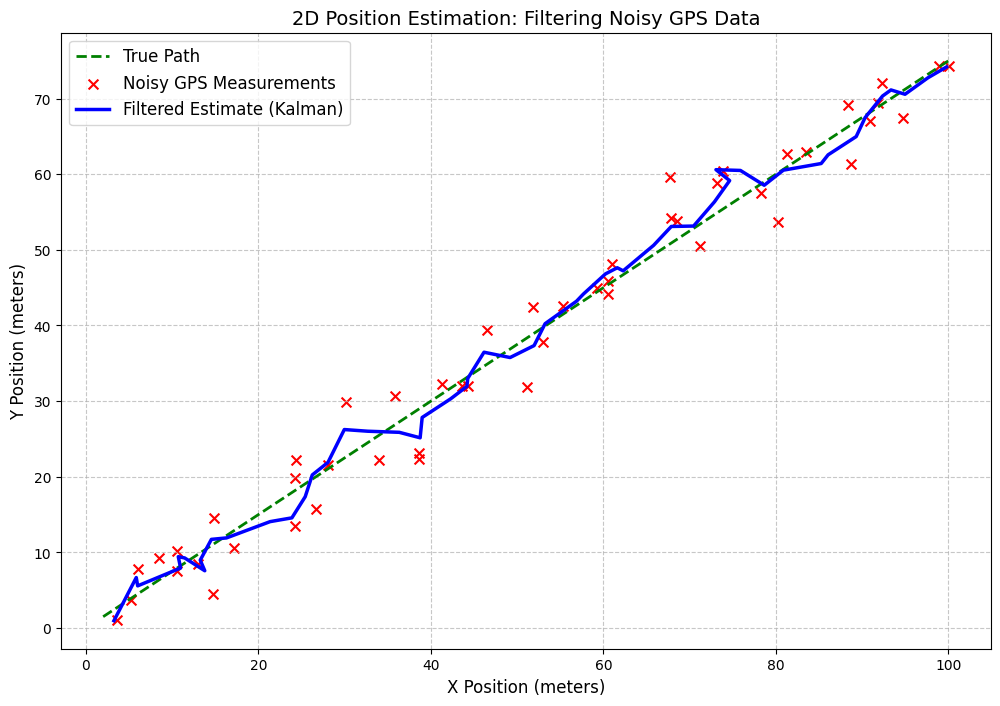

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters & Matrices (From Part A)
# ==========================================
dt = 1.0  # Time step

# State transition matrix (A)
A = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])

# Measurement matrix (H) - extracts px and py
H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])

# Process noise matrix (G)
G = np.array([[0.5 * dt**2, 0],
              [0, 0.5 * dt**2],
              [dt, 0],
              [0, dt]])

# Covariance Matrices
# sigma_p: Variance in acceleration (process noise)
sigma_p = np.array([[0.2, 0],
                    [0, 0.2]])
Q = G @ sigma_p @ G.T  # Full process noise covariance

# sigma_m: Variance in GPS measurement (measurement noise)
sigma_m = np.array([[10.0, 0],
                    [0, 10.0]])
R = sigma_m

# ==========================================
# 2. Generate Synthetic Noisy GPS Data
# ==========================================
np.random.seed(42)
num_steps = 50

# True state: [x, y, v_x, v_y]
true_state = np.array([0, 0, 2.0, 1.5])
true_positions = []
gps_measurements = []

for _ in range(num_steps):
    # Move object along true trajectory
    true_state = A @ true_state
    true_positions.append((true_state[0], true_state[1]))

    # Add random Gaussian noise to create a realistic GPS reading
    noise = np.random.multivariate_normal([0, 0], R)
    gps_reading = H @ true_state + noise
    gps_measurements.append(gps_reading)

true_positions = np.array(true_positions)
gps_measurements = np.array(gps_measurements)

# ==========================================
# 3. Kalman Filter Algorithm
# ==========================================
# Initial State Guess
x_est = np.array([0, 0, 0, 0])
# Initial Covariance Guess (High uncertainty)
P_est = np.eye(4) * 50

filtered_positions = []

for y in gps_measurements:
    # --- Prediction Step (Time Update) ---
    x_pred = A @ x_est
    P_pred = A @ P_est @ A.T + Q

    # --- Update Step (Measurement Update) ---
    # Innovation Covariance (S)
    S = H @ P_pred @ H.T + R

    # Kalman Gain (K)
    K = P_pred @ H.T @ np.linalg.inv(S)

    # Updated State Estimate
    x_est = x_pred + K @ (y - H @ x_pred)

    # Updated Covariance Estimate
    P_est = (np.eye(4) - K @ H) @ P_pred

    # Store the filtered position [x, y]
    filtered_positions.append((x_est[0], x_est[1]))

filtered_positions = np.array(filtered_positions)

# ==========================================
# 4. Plot the Results
# ==========================================
plt.figure(figsize=(12, 8))

# Plot True Path
plt.plot(true_positions[:, 0], true_positions[:, 1], 'g--', linewidth=2, label='True Path')

# Plot Noisy GPS Measurements
plt.scatter(gps_measurements[:, 0], gps_measurements[:, 1], color='red', marker='x', s=50, label='Noisy GPS Measurements')

# Plot Kalman Filter Estimate
plt.plot(filtered_positions[:, 0], filtered_positions[:, 1], 'b-', linewidth=2.5, label='Filtered Estimate (Kalman)')

# Formatting
plt.title('2D Position Estimation: Filtering Noisy GPS Data', fontsize=14)
plt.xlabel('X Position (meters)', fontsize=12)
plt.ylabel('Y Position (meters)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Display Plot
plt.show()